# Archetypal analysis of clonal embeddings

On blobby embeddings, clustering can be compromised (which was one of the reasons for the creation of `clone2vec` at the first place). But clonal embeddings themselves can be blobby. It happens due to combination of three reasons:
1. continual changes in cell type proportions,
2. undefined borders between cell types,
3. instability of the small clones positioning on the embedding.

If you have lots of clones, inclusion of only big clones can help with the third option, and a reasonable selection of the embedding method (e.g. using `Concord` instead of just PCA) can help with the second one. But still, sometimes we can't improve clustering borders in the clonal embedding, but still want to describe heterogeneity of clones.

Instead of doing Leiden clustering, we're suggesting using archetypal analysis in the `clone2vec` space with `partipy` Python package.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import clone2vec as c2v
import partipy as pt

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

In [2]:
adata = c2v.datasets.Liu_NSCLC_CD8(embedding_type="gex")
clones = c2v.datasets.Liu_NSCLC_CD8(embedding_type="c2v")

using gene expression embedding
using clonal embedding (compositions in adata.X)


To select a right number of archetypes, we can see a few metrics:
1. explained variance by each number of archetype,
2. information criteria plot,
3. bootstrap-stability.

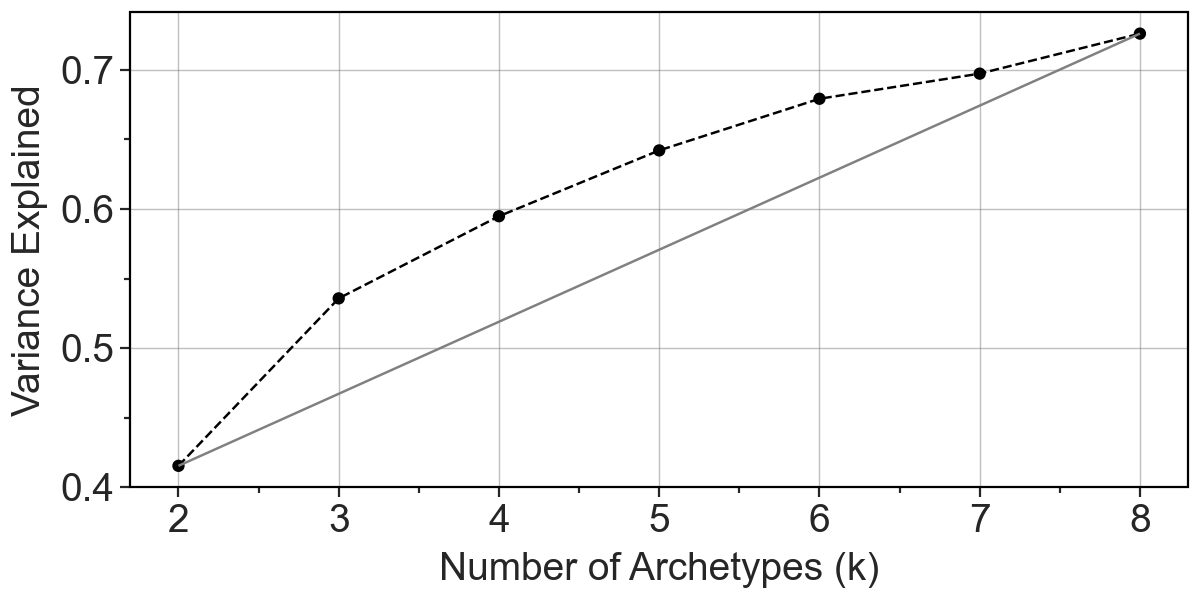

In [3]:
pt.set_obsm(adata=clones, obsm_key="clone2vec", n_dimensions=10)
pt.compute_selection_metrics(adata=clones, n_archetypes_list=range(2, 9))
pt.plot_var_explained(clones)

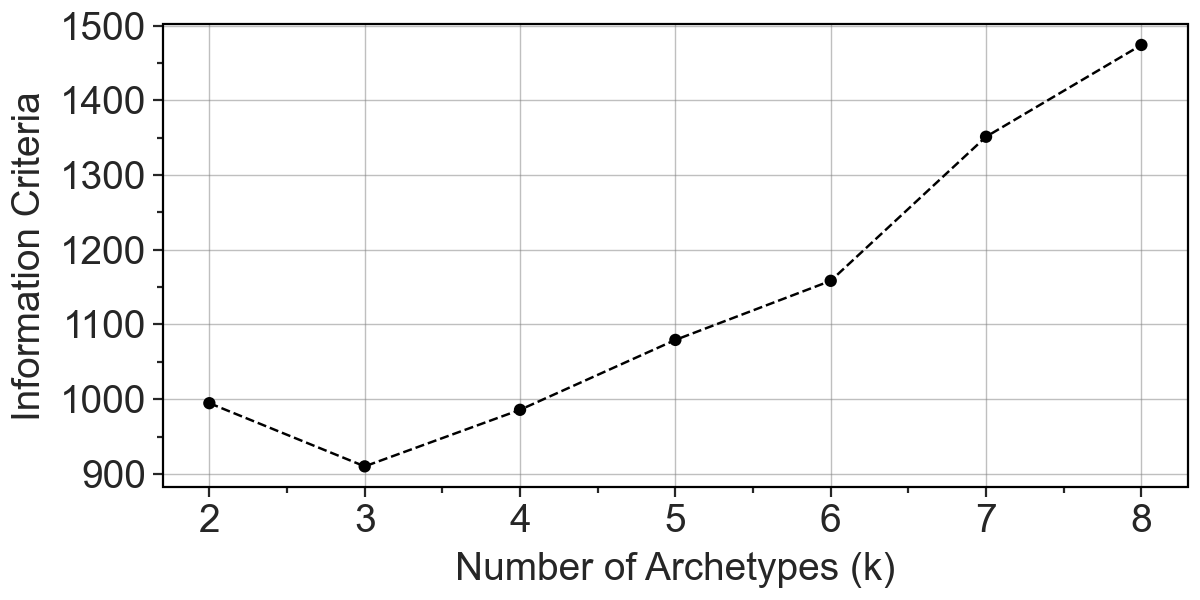

In [4]:
pt.plot_IC(clones)

In [5]:
pt.compute_bootstrap_variance(
    adata=clones,
    n_bootstrap=100,
    n_archetypes_list=range(2, 9),
    verbose=True,
)

Testing 8 Archetypes: 100%|██████████| 100/100 [00:00<00:00, 243.42it/s]


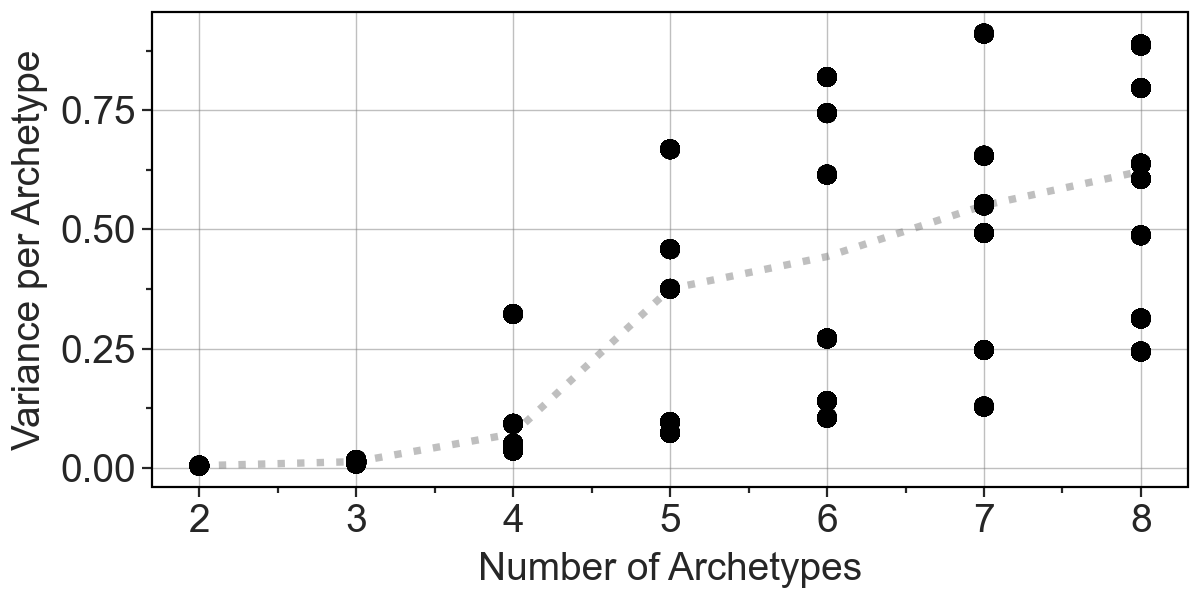

In [6]:
pt.plot_bootstrap_variance(clones, summary_method="median")

Here, based on IC, we decided to go for three archetypes. After that we can visually inspect weight of each clone in 3 archetypes-representation.

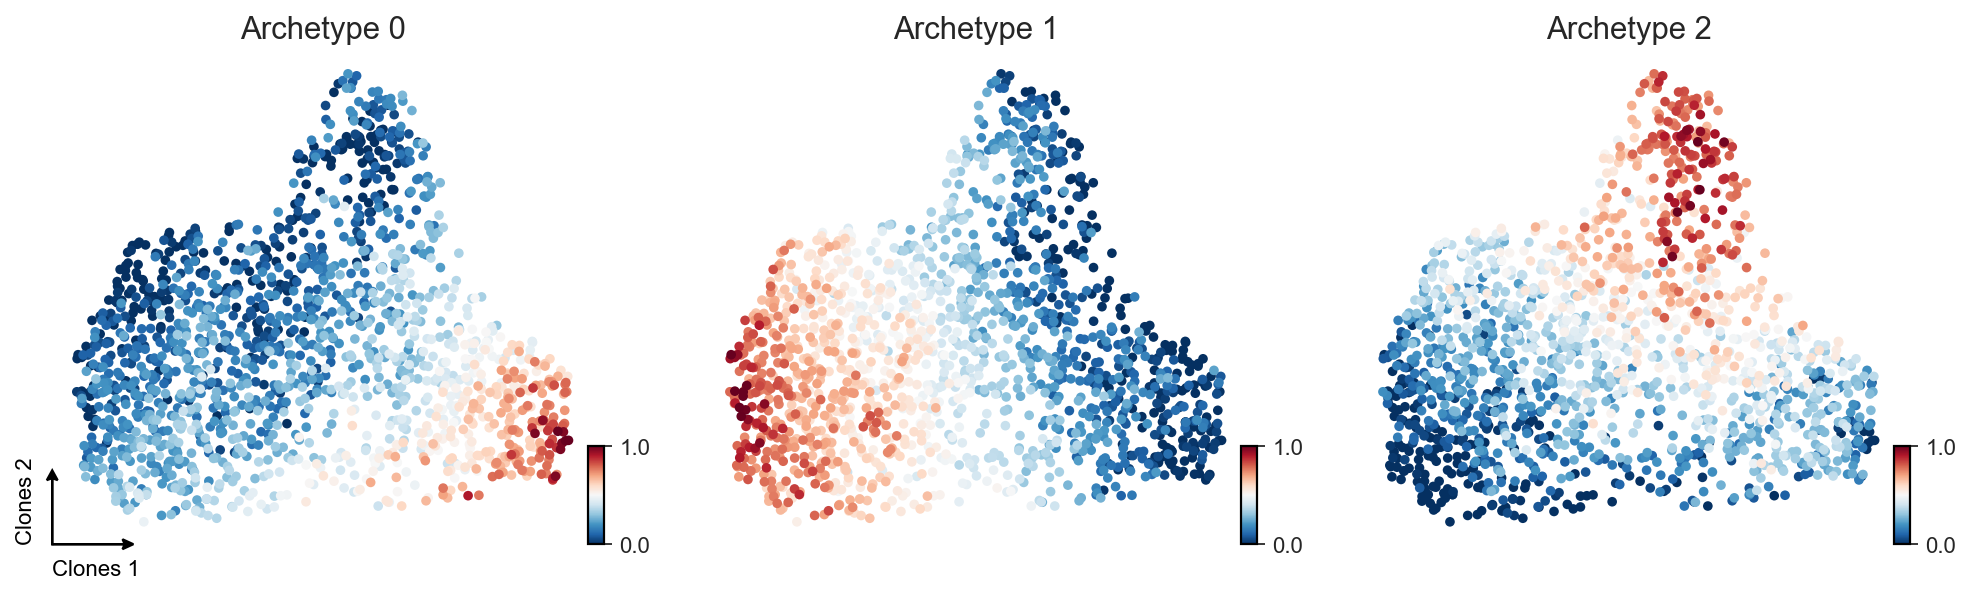

In [7]:
clones.obsm["X_AA"] = pt.get_aa_result(clones, n_archetypes=3)["A"]

axes = c2v.pl.embedding(clones, obsm_name="X_AA", obsm_component=[0, 1, 2],
                        frameon=False, show=False, cmap="RdBu_r",
                        title=["Archetype 0", "Archetype 1", "Archetype 2"])

c2v.pl.embedding_axis(axes[0], label="Clones")
c2v.pl.small_cbar(axes)

Based on these weights, we can transform archetypes into clusters via either hard-clustering-like assignment (we're looking which archetype has the biggest weight for each clone) or soft-clustering-like one (similar to the first strategy, but with additional threshold for the minimal archetype weight).

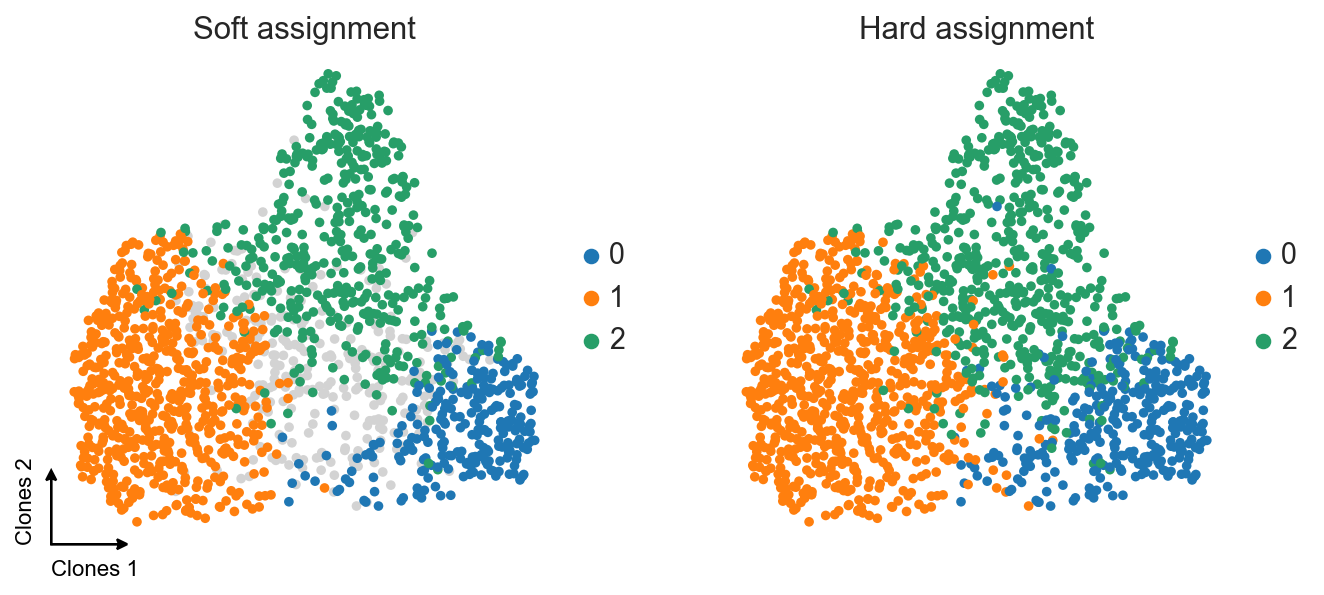

In [8]:
confidence_level = 0.5

clones.obs["AA_hard"] = np.argmax(clones.obsm["X_AA"], axis=1)
clones.obs["AA_soft"] = [
    clones.obs["AA_hard"].iloc[i] if j > 0 else -1
    for i, j in enumerate((clones.obsm["X_AA"] >= confidence_level).sum(axis=1))
]

clones.obs["AA_hard"] = clones.obs["AA_hard"].astype("category")
clones.obs["AA_soft"] = clones.obs["AA_soft"].astype("category")

axes = sc.pl.umap(
    clones,
    color=["AA_soft", "AA_hard"],
    palette={
        -1: "lightgrey",
        0: sns.color_palette()[0],
        1: sns.color_palette()[1],
        2: sns.color_palette()[2],
    },
    title=["Soft assignment", "Hard assignment"],
    frameon=False,
    groups=[0, 1, 2],
    na_in_legend=False,
    show=False,
)
c2v.pl.embedding_axis(axes[0], label="Clones")

Archetype weights also give us a possibility to find gene expression assosiations via correlation analysis, and not just simple differential expression testing.

In [9]:
clones = c2v.pp.transfer_expression(adata, clones)

summarizing expression at clone level: 
    using `adata.X` as expression source
    finished (0:00:07): created clone-level AnnData with
     .X aggregated expression matrix (clones × genes)
     .uns['transfer_expression'] dict with 'strategy'
     .uns['mask_key'] string with obsm key for boolean mask of clones with non-zero cells
     .obsm['counts'] dataframe of features
     .obsm['proportions'] dataframe of features


In [10]:
c2v.tl.associations(clones, response_key="X_AA")

computing feature–response associations: 
    using `adata.X` as features
    using `adata.obsm['X_AA']` as response
    computed 'pearson' statistics for 'X' features
    finished (0:00:01): added
     .varm['<response_key>:<feature matrix>:pearson:r'] matrix with correlation coefficients
     .varm['<response_key>:<feature matrix>:pearson:pvalue'] matrix with uncorrected p-values
     .varm['<response_key>:<feature matrix>:pearson:slope'] matrix with regression slopes coefficients
     .varm['<response_key>:<feature matrix>:pearson:p_adj'] matrix with corrected p-values


In [11]:
print(
    "Archetype 0 correlations:",
    clones.varm["X_AA:X:pearson:r"]["X_AA:0"].dropna().sort_values(ascending=False).head(5),
    "", "Archetype 1 correlations:",
    clones.varm["X_AA:X:pearson:r"]["X_AA:1"].dropna().sort_values(ascending=False).head(5),
    "", "Archetype 2 correlations:",
    clones.varm["X_AA:X:pearson:r"]["X_AA:2"].dropna().sort_values(ascending=False).head(5),
    sep="\n",
)

Archetype 0 correlations:
CXCL13    0.674131
LAYN      0.672333
CTLA4     0.668017
HAVCR2    0.666067
ENTPD1    0.654256
Name: X_AA:0, dtype: float64

Archetype 1 correlations:
GZMK     0.814815
CST7     0.585591
CMC1     0.573601
RPL28    0.541970
KLRG1    0.509160
Name: X_AA:1, dtype: float64

Archetype 2 correlations:
S100A4    0.585500
HOPX      0.563047
S100A6    0.491612
ZNF683    0.487993
IL7R      0.434046
Name: X_AA:2, dtype: float64


And we see the same set of signatures that we obtained in the paper. Hooray!